<div align="center">

#### [S. Mussard](https://sites.google.com/view/cv-stphane-mussard/accueil "Homepage") 

</div>

<div align="center">

#### Chapter 7: Gini-PLS Regressions 

</div>


<div align="center"> <a href="https://www.python.org/"><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/f/f8/Python_logo_and_wordmark.svg/390px-Python_logo_and_wordmark.svg.png" style="max-width: 150px; display: inline" alt="Python"/></a> 

</div>


<div align="center"> </div>

<div align="center">

Cite: S. Mussard (2025), *Machine Learning with Gini Indices: Applications with Python*, Springer.  

</div>



In [1]:
#!pip install outliers
#!pip install outlier_utils
#!pip install iteration_utilities
#!pip install openpyxl
#!pip install mlxtend

In [2]:
from PLS import GiniPLS
import pandas as pd
import numpy as np
%matplotlib inline

In [3]:
data = pd.read_excel('cars_pls.xls', index_col=0)  
y = data['capacity']
X = data.drop('capacity', axis = 1)
X.head()

,power,speed,weight,length,width
cars,,,,,
honda civic,90,174,850,369,166
renault 19,92,180,965,415,169
fiat tipo,83,170,970,395,170
peugeot 405,90,180,1080,440,169
renault 21,88,180,1135,446,170


In [4]:
X.corr()


,power,speed,weight,length,width
power,1.000000,0.922016,0.493175,0.402979,0.690944
speed,0.922016,1.000000,0.488920,0.460687,0.618632
weight,0.493175,0.488920,1.000000,0.917105,0.768091
length,0.402979,0.460687,0.917105,1.000000,0.794105
width,0.690944,0.618632,0.768091,0.794105,1.000000


In [5]:
model = GiniPLS() # Instantiation
model.fit(y, X, method = 'Gini1-PLS1', n_components = 3) 
model.cross_validation()

Q2 statistics: [ 0.8928 -0.9954 -2.9626]


In [6]:
model.cross_validation(n_splits=3)

Q2 statistics: [ 0.891  -2.4365 -6.8682]


In [7]:
model.cross_validation(n_splits=3, random_state=42)

Q2 statistics: [ 0.8958 -0.5527 -1.3966]


In [8]:
model.fit(y, X, method = 'Gini1-PLS1', n_components = 1) # ou 'Gini2-PLS1' ou 'Gini3-PLS1' ou PLS
model.summary()

                                 PLS Gini Regression                                 
Dep. Variable:                         y     R-squared:                        0.9059
Model:               Gini PLS Regression     Df Residuals:                         23
Method:                       Gini1-PLS1     No. Outliers in x:                     3
Date:                   Sat, 27 Sep 2025     Time:                           13:48:26
Breusch-Pagan p-val:              0.0153     Durbin Watson:                    1.7783
                         Regression Gini1-PLS1                         
 Variables   Coeff   Std err     t     P>|t|   [0.025   0.975] 
---------------------------------------------------------------
         t1  0.5008     0.033 15.1984     0.0   0.4362   0.5654
---------------------------------------------------------------
                 Stats on Features
--------------------------------------------------------------
   Variables  Coefficients     VIP      VIF Outliers
1  In

In [9]:
from sklearn.cross_decomposition import PLSRegression
pls = PLSRegression(n_components=1)
pls.fit(X, y)
intercept = np.mean(y)
print("Intercept:", intercept)
print("Coefficients:", "\n", pls.coef_)

Intercept: 2009.84
Coefficients: 
 [[180.37645485]
 [173.91446875]
 [159.72621202]
 [144.61410641]
 [164.73185636]]


c:\Users\smussa01\Anaconda3\lib\site-packages\sklearn\cross_decomposition\_pls.py:503: FutureWarning: The attribute `coef_` will be transposed in version 1.3 to be consistent with other linear models in scikit-learn. Currently, `coef_` has a shape of (n_features, n_targets) and in the future it will have a shape of (n_targets, n_features).
  warnings.warn(


In [10]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=8)
model.fit(y_train, X_train, method = 'PLS', n_components =1)
y_pred = model.predict(X_test)
print("Resids PLS", y_test - y_pred)

model.fit(y_train, X_train, method = 'Gini1-PLS1', n_components =1)
y_pred = model.predict(X_test)
print("Resids Gini1-PLS1", y_test - y_pred)

model.fit(y_train, X_train, method = 'Gini3-PLS1', n_components =1)
y_pred = model.predict(X_test)
print("Resids Gini3-PLS1", y_test - y_pred)


Predicted values in the initial space: 
 [1048.8731 2480.8559 1956.1233 1384.1    1392.1306] 

Resids PLS cars
ford fiesta         68.126859
ford scorpio       452.144091
renault 21         111.876750
seat ibiza sx i     76.899973
honda civic          3.869383
Name: capacity, dtype: float64
Predicted values in the initial space: 
 [1882.4222 2142.2875 2047.9076 1937.6801 1938.1654] 

Resids Gini1-PLS1 cars
ford fiesta       -765.422197
ford scorpio       790.712457
renault 21          20.092443
seat ibiza sx i   -476.680126
honda civic       -542.165393
Name: capacity, dtype: float64
Predicted values in the initial space: 
 [1045.7421 2505.9983 1975.6507 1356.2519 1358.9787] 

Resids Gini3-PLS1 cars
ford fiesta         71.257902
ford scorpio       427.001671
renault 21          92.349271
seat ibiza sx i    104.748107
honda civic         37.021255
Name: capacity, dtype: float64


In [11]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

In [12]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

  :Number of Instances: 442

  :Number of Attributes: First 10 columns are numeric predictive values

  :Target: Column 11 is a quantitative measure of disease progression one year after baseline

  :Attribute Information:
      - age     age in years
      - sex
      - bmi     body mass index
      - bp      average blood pressure
      - s1      tc, total serum cholesterol
      - s2      ldl, low-density lipoproteins
      - s3      hdl, high-density lipoproteins
      - s4      tch, total cholesterol / HDL
      - s5      ltg, possibly log of serum triglycerides level
      - s6      glu, blood sugar level

Note: Each of these 1

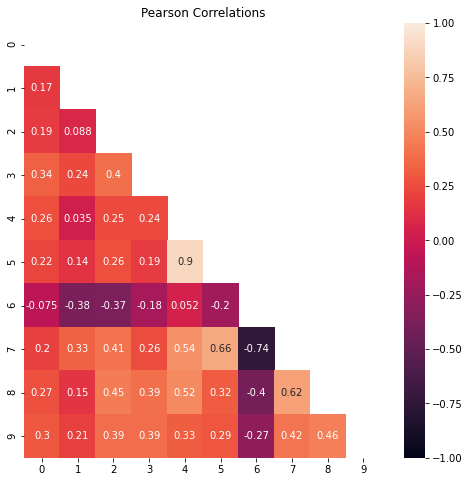

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.DataFrame(X)
plt.figure(figsize=(8,8))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), annot=True, mask=mask, vmin=-1, vmax=1)
plt.title('Pearson Correlations')
plt.show()

In [14]:
#OLS
import statsmodels.api as sm
import statsmodels.regression.linear_model as sm_lm
x = sm.add_constant(X)
model_ols = sm.OLS(y,x)
results = model_ols.fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     46.27
Date:                Sat, 27 Sep 2025   Prob (F-statistic):           3.83e-62
Time:                        13:48:27   Log-Likelihood:                -2386.0
No. Observations:                 442   AIC:                             4794.
Df Residuals:                     431   BIC:                             4839.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.576     59.061      0.0

                                 PLS Gini Regression                                 
Dep. Variable:                         y     R-squared:                        0.5086
Model:               Gini PLS Regression     Df Residuals:                        439
Method:                       Gini3-PLS1     No. Outliers in x:                     7
Date:                   Sat, 27 Sep 2025     Time:                           13:48:27
Breusch-Pagan p-val:              0.0007     Durbin Watson:                    2.0088
                         Regression Gini3-PLS1                         
 Variables   Coeff   Std err     t     P>|t|   [0.025   0.975] 
---------------------------------------------------------------
         t1  0.3351    0.0176 19.0322     0.0   0.3006   0.3696
         t2  0.2942    0.0305  9.6572     0.0   0.2345   0.3539
---------------------------------------------------------------
                 Stats on Features
---------------------------------------------------------

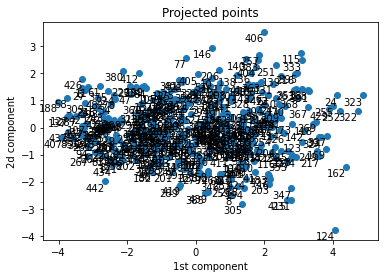

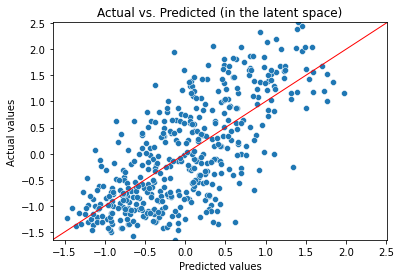

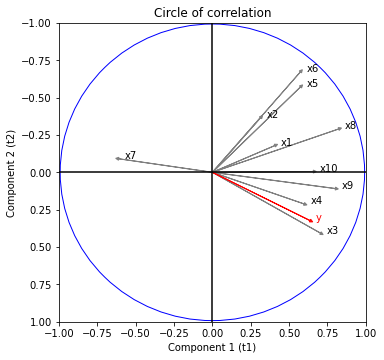

In [15]:
model = GiniPLS() # Instantiation
model.fit(y, X, method = 'Gini3-PLS1', n_components = 2)
model.summary()
model.plot()